# Sun–Abraham event study — pre- and post-adoption effects, four reference periods
# Fig S8
Draws the full event-study profile from **`SA_event_study_all_references.csv`**.

**Input columns**

| column | meaning |
|---|---|
| `crop` | `corn` / `soy` |
| `reference` | `k=-4:-3`, `k=-2:-1`, `k=-4:-1`, `k<0` |
| `fe` | `field + year` or `field + year^state` |
| `rel` | relative-period bin |
| `k_order` | ordering key, `-1` at the last pre-adoption cell, `0` at adoption |
| `period` | `pre` / `post` |
| `duration` | low-till years, post cells only (`duration = k + 1`) |
| `is_reference` | `TRUE` if the cell is folded into the omitted category |
| `estimate`, `std_error` | log points |
| `pct`, `pct_lo`, `pct_hi` | percent effect and 95% CI |

**Read `is_reference` carefully.** Those cells have **no coefficient** — they *are* the
baseline. They are stored with `pct = 0` and empty CIs and drawn as open markers. How much
of the pre-period survives differs by column:

| reference | pre-adoption cells still estimable |
|---|---|
| `k = -4:-3` | ≤−11, −10:−8, −7:−5, **−2, −1** |
| `k = -2:-1` | ≤−11, −10:−8, −7:−5, −4:−3 |
| `k = -4:-1` | ≤−11, −10:−8, −7:−5 |
| `k < 0` | none |

Per-reference files are also provided: `SA_event_study_k_m4_m3.csv`,
`SA_event_study_k_m2_m1.csv`, `SA_event_study_k_m4_m1.csv`, `SA_event_study_k_lt_0.csv`.

On Colab with Drive:

```python
from google.colab import drive; drive.mount('/content/drive')
CSV = '/content/drive/MyDrive/<your folder>/SA_event_study_all_references.csv'
```

In [8]:
# ---- Sun-Abraham event study: pre- and post-treatment effects, 4 reference periods ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CSV     = "../output_linear_1999_2023/11_SA/SA_event_study_all_references.csv"       # <-- point at your copy
OUT_PNG = "output/FigS_SA_event_study_references.png"
OUT_PDF = "output/FigS_SA_event_study_references.pdf"

# palette: colourblind-safe categorical slots 1-2, plus neutrals
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTE, GRID = "#0b0b0b", "#52514e", "#8a8a86", "#e6e6e2"

REL = ["<=-11", "-10:-8", "-7:-5", "-4:-3", "-2", "-1",
       "0", "1:3", "4:8", "9:13", "14:18", ">=19"]
REFS = ["k=-4:-1", "k<0"]
RLAB = {"k=-4:-1": "reference  k = -4:-1", "k<0": "reference  all k < 0"}
CROPS = [("corn", "Corn"), ("soy", "Soybean")]
STYLE = {"field + year":       dict(c=ORANGE,   ls="-",         mk="o", dx=-0.11),
         "field + year^state": dict(c='green', ls=(0, (3, 2)), mk="s", dx=+0.11)}
ADOPT = 5.5      # boundary between the k = -1 cell and the k = 0 cell

## Load

`is_reference` is normalised to a real boolean so the pinned cells can be split out when plotting.

In [9]:
df = pd.read_csv(CSV)
df["x"] = df["rel"].map({r: i for i, r in enumerate(REL)})
df["is_reference"] = df["is_reference"].astype(str).str.upper().eq("TRUE")
print(df.groupby(["reference","period"])["is_reference"].agg(["size","sum"]))

                  size  sum
reference period           
k<0       post      24    0
          pre       24   24
k=-2:-1   post      24    0
          pre       24    8
k=-4:-1   post      24    0
          pre       24   12
k=-4:-3   post      24    0
          pre       24    4


## Draw

Two series per panel (the two fixed-effect structures), dodged horizontally. The line runs through the pinned reference cells so each profile reads as continuous; only estimated cells get a filled marker and a confidence interval.

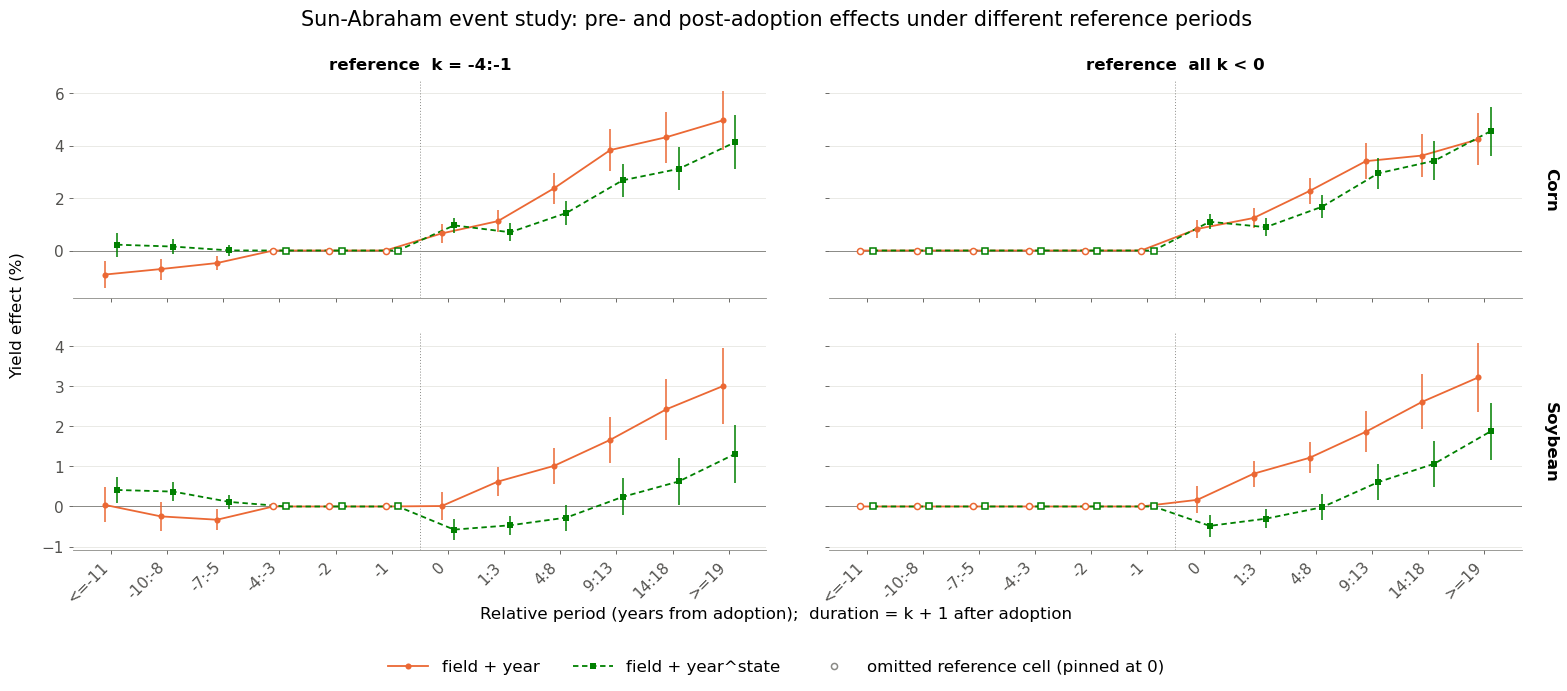

In [12]:
fig, axes = plt.subplots(len(CROPS), 2, figsize=(15.8, 6.8),
                         sharex=True, sharey="row")
for ri, (crop, clab) in enumerate(CROPS):
    for ci, ref in enumerate(['k=-4:-1', 'k<0']):
        ax = axes[ri, ci]
        sub = df[(df["crop"] == crop) & (df["reference"] == ref)]
        for fe, s in STYLE.items():
            d = sub[sub["fe"] == fe].sort_values("x")
            xd = d["x"] + s["dx"]
            # connect through the pinned reference cells so the profile is continuous
            ax.plot(xd, d["pct"], ls=s["ls"], color=s["c"], lw=1.3, zorder=2)
            e = d[~d["is_reference"]]
            ax.vlines(e["x"] + s["dx"], e["pct_lo"], e["pct_hi"],
                      color=s["c"], lw=1.1, zorder=2)
            ax.plot(e["x"] + s["dx"], e["pct"], s["mk"], color=s["c"],
                    mfc=s["c"], mew=0, ms=4.4, zorder=3)
            r = d[d["is_reference"]]
            ax.plot(r["x"] + s["dx"], r["pct"], s["mk"], color=s["c"],
                    mfc="white", mew=1.1, ms=4.4, zorder=3)

        ax.axhline(0, color=MUTE, lw=0.7, zorder=1)
        ax.axvline(ADOPT, color=MUTE, lw=0.7, ls=(0, (1, 2)), zorder=1)
        if ri == 0:
            ax.set_title(RLAB[ref], fontsize=12, fontweight="bold", pad=8)
        if ci == len(REFS) - 1:
            ax.text(1.03, 0.5, clab, transform=ax.transAxes, rotation=270,
                    va="center", ha="left", fontsize=12, fontweight="bold")
        ax.set_xticks(range(len(REL)))
        ax.set_xticklabels(REL, rotation=45, ha="right", fontsize=12)
        ax.yaxis.grid(True, color=GRID, lw=0.6)
        ax.xaxis.grid(False)
        ax.set_axisbelow(True)
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)
        ax.spines["bottom"].set_color(MUTE)
        ax.spines["bottom"].set_linewidth(0.6)
        ax.tick_params(colors=INK2, labelsize=11, length=3, width=0.6)

fig.supylabel("Yield effect (%)", fontsize=12, x=0.015)
fig.supxlabel("Relative period (years from adoption);  duration = k + 1 after adoption",
              fontsize=12, y=0.05)

handles = [Line2D([0], [0], color=s["c"], ls=s["ls"], lw=1.3, marker=s["mk"],
                  mfc=s["c"], mew=0, ms=4.4, label=fe) for fe, s in STYLE.items()]
handles.append(Line2D([0], [0], color=MUTE, ls="none", marker="o", mfc="white",
                      mew=1.1, ms=4.4, label="omitted reference cell (pinned at 0)"))
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=3, frameon=False, fontsize=12, handlelength=2.4)

fig.suptitle("Sun-Abraham event study: pre- and post-adoption effects under different "
             "reference periods", x=0.5, y=0.95, ha="center", fontsize=15)
# fig.text(0.035, 0.955,
#          "Dotted vertical line marks adoption. Open markers are cells folded into the "
#          "omitted category, which have no coefficient by construction.",
#          ha="left", va="top", fontsize=8.8, color=INK2)
# fig.text(0.035, 0.008,
#          "Reference cells differ by column, so only the k = -4:-3 window leaves k = -1 "
#          "estimable. Under all k < 0 the whole pre-period is pinned and cannot test for "
#          "pre-trends.\nBars are 95% CIs, county-clustered. Y scales are shared within "
#          "each row, so profiles are comparable across columns but not across rows.",
#          ha="left", va="bottom", fontsize=7.3, color=MUTE)

fig.subplots_adjust(left=0.055, right=0.972, top=0.845, bottom=0.155,
                    wspace=0.09, hspace=0.16)
plt.show()

## Save

In [6]:
fig.savefig(OUT_PNG, dpi=320)
fig.savefig(OUT_PDF)
print("wrote", OUT_PNG, "and", OUT_PDF)

wrote output/FigS_SA_event_study_references.png and output/FigS_SA_event_study_references.pdf
